# 순차 데이터와 기본 RNN

순차 데이터는 값의 순서가 의미를 결정하는 데이터이다. 자연어에서는 같은 단어를 사용해도 배열 순서가 달라지면 문장의 의미가 달라지므로, 단어의 존재 여부뿐 아니라 앞뒤 문맥을 함께 처리해야 한다.

RNN(Recurrent Neural Network)은 현재 토큰의 입력과 이전 위치의 은닉 상태를 함께 계산하여 순서 정보를 전달하는 신경망이다. 문장 분류, 시계열 예측, 음성 처리처럼 이전 위치의 정보가 다음 판단에 영향을 주는 작업에 사용한다.

이 노트북에서는 작은 텐서로 RNN의 입출력 shape와 마지막 은닉 상태를 확인한 뒤, 상승·하강 시퀀스를 구분하는 분류기를 학습한다. 실제 리뷰 데이터에 RNN을 적용하는 과정은 NSMC 노트북에서 다룬다.


## 01. 순차 데이터와 순서 정보

순차 데이터(Sequential Data)는 값의 위치와 순서가 관계를 결정하는 데이터이다. 순서대로 묶인 한 사례를 **시퀀스(Sequence)** 라 하고, 모델이 그 시퀀스에서 한 번에 처리하는 위치를 **타임 스텝(Time Step)** 이라 한다. 자연어에서는 문장 하나가 시퀀스이고 각 토큰 위치가 타임 스텝에 해당한다.

`좋다 → 정말`과 `정말 → 좋다`처럼 같은 원소를 포함해도 배열 순서가 다르면 서로 다른 시퀀스이다. BoW는 두 표현의 단어 개수를 같게 만들 수 있어 어순 차이를 잃지만, 순차 모델은 한 위치의 계산 결과를 다음 위치로 전달하여 앞뒤 관계를 구분한다. 따라서 부정어의 위치, 단어 순서, 시간에 따른 상승·하강처럼 **언제 등장했는가**가 중요한 작업에 필요하다.

다음 코드는 같은 값을 역순으로 배치한다. 출력에서 두 합이 모두 `10.0`인데 위치별 비교가 `False`인 것을 확인하면, 순차 모델이 합계나 원소 집합 외에 시간축의 배열을 입력으로 보존해야 하는 이유를 알 수 있다.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)

ascending = torch.tensor([1.0, 2.0, 3.0, 4.0])
descending = torch.flip(ascending, dims=[0])

print("오름차순 시퀀스:", ascending.tolist())
print("내림차순 시퀀스:", descending.tolist())
print("두 시퀀스의 합:", ascending.sum().item(), descending.sum().item())
print("같은 위치의 값이 모두 같은가:", torch.equal(ascending, descending))


오름차순 시퀀스: [1.0, 2.0, 3.0, 4.0]
내림차순 시퀀스: [4.0, 3.0, 2.0, 1.0]
두 시퀀스의 합: 10.0 10.0
같은 위치의 값이 모두 같은가: False


## 02. RNN의 입력·출력·은닉 상태

RNN(Recurrent Neural Network)은 현재 위치의 입력 $x_t$와 바로 이전 위치의 은닉 상태 $h_{t-1}$를 함께 사용해 새 은닉 상태 $h_t$를 만드는 순환 신경망이다. 같은 가중치를 모든 타임 스텝에 반복 적용하므로 길이가 달라져도 같은 규칙으로 순서를 읽을 수 있다. 은닉 상태(Hidden State)는 현재까지 읽은 내용을 고정 길이 벡터로 요약해 다음 위치로 전달하는 통로이다.

$$h_t = \tanh(W_{ih}x_t + b_{ih} + W_{hh}h_{t-1} + b_{hh})$$

이 식에서 $x_t$는 현재 토큰의 특성 벡터이고 $h_{t-1}$는 앞 위치까지의 요약이다. 현재 입력만 계산하는 완전연결층과 달리 $h_{t-1}$가 매 단계 다시 들어가므로 이전 순서 정보가 뒤 위치의 판단에 영향을 줄 수 있다.

![image.png](attachment:b56c5865-0573-484e-b79d-65262e99a030.png)


`batch_first=True`이면 입력 shape는 `(배치 크기, 시퀀스 길이, 입력 특성 수)`이다. 가운데 축이 시간축이며 모델은 이 축을 앞에서 뒤로 순회한다. `nn.RNN(input_size=3, hidden_size=5)`는 각 위치의 3개 입력 특성을 5개 은닉 특성으로 바꾸고 다음 두 텐서를 반환한다.

- **`output`**: 모든 타임 스텝의 은닉 상태를 모은 `(배치, 시퀀스 길이, 은닉 특성 수)` 텐서
- **`hidden`**: 마지막 타임 스텝 뒤에 각 층에 남은 `(층 수 × 방향 수, 배치, 은닉 특성 수)` 텐서

다음 코드의 `(2, 4, 3)` 입력은 시퀀스 2개, 각 4개 위치, 위치마다 특성 3개를 뜻한다. 결과가 `output=(2, 4, 5)`, `hidden=(1, 2, 5)`이고 마지막 위치 비교가 `True`이면 시간축 전체를 보관하는 `output`과 최종 요약인 `hidden`의 차이를 확인한 것이다. 한 층의 단방향 RNN에서는 `output[:, -1, :]`와 `hidden[-1]`이 같은 마지막 은닉 상태를 가리킨다.


### RNN이 순서를 읽는 과정

![현재 입력과 이전 은닉 상태로 새 은닉 상태를 만들고 시간축을 따라 전달하는 RNN 구조](attachment:rnn_time_flow_infographic.png)

그림의 네 RNN 상자는 서로 다른 네 층을 뜻하지 않는다. 하나의 RNN 셀과 같은 가중치를 네 타임 스텝에 반복 적용한 모습이다. 각 위치에서는 현재 입력 $x_t$와 이전 위치까지의 요약 $h_{t-1}$를 함께 계산하여 새 은닉 상태 $h_t$를 만들고 다음 위치로 전달한다. 위로 표시된 주황색 $h_t$와 오른쪽으로 전달되는 보라색 $h_t$는 같은 은닉 상태이며, 위쪽에서는 `output`에 모으고 오른쪽에서는 다음 타임 스텝의 이전 상태로 사용한다.

`output`은 $h_1$부터 $h_L$까지 모든 위치의 은닉 상태를 모으고, `hidden`은 마지막 위치까지 처리한 뒤 각 층에 남은 은닉 상태를 모은다. 그림 아래의 `output`과 `hidden`은 앞 결과를 뒤 결과로 변환하는 두 단계가 아니라 하나의 `nn.RNN` 호출이 함께 반환하는 두 결과이다.

다음 코드에서는 `B=2`, `L=4`, `F=3`, `H=5`이므로 입력 `(2, 4, 3)`에서 `output=(2, 4, 5)`와 `hidden=(1, 2, 5)`가 나온다. 한 층의 단방향 RNN에서는 마지막 위치를 선택한 `output[:, -1, :]`와 마지막 층을 선택한 `hidden[-1]`이 모두 `(2, 5)`이며 같은 값을 가진다.

In [3]:

batch_size = 2  # RNN 모델이 한 번에 처리할 문장의 수

# 문장마다 저장된 토큰 위치의 개수 (== 토큰 개수)
sequence_length = 4 # 문장마다 RNN이 순서대로 처리하는 토큰 위치가 4개
                    #
input_size = 3  # 토큰 하나를 표현하는 입력 벡터 차원

hidden_size = 5 # 토큰을 읽은 뒤 만드는 은닉 상태 벡터 차원


# 샘플 데이터 생성 (임의로 벡터화된 데이터 생성)

# 2개의 시퀀스(문장)이 각각 4개의 위치(토큰)와 위치별 3개의 특성(벡터)을 가지도록 입력 데이터를 생성
rnn_input = torch.arange(
    batch_size * sequence_length * input_size,  # 벡터 3개로 구성된 4개의 토큰이 2개의 문장으로 있음.
    dtype=torch.float32
).reshape(batch_size, sequence_length, input_size) / 10
# (2,4,3)


# RNN 계층 생성
# batch_first = True: 배치 축을 첫 번째에 두는 (B, L, F) 입력을 사용 < Batch, Layer, Feature_size == input_size >
rnn = nn.RNN(   # batch 사이즈 지정 시 서로에게 영향을 미치지 않고 병렬적으로 학습 진행됨
    input_size=input_size,      # 토큰 벡터 길이
    hidden_size=hidden_size,    # 기억 벡터 크기
    batch_first=True,           # 배치 축을 선정하는 옵션
)

# output: 모든 위치의 은닉 상태
# hidden: 마지막 위치 이후 층별 은닉 상태
output, hidden = rnn(rnn_input)

print("입력 shape:", rnn_input.shape)

# output: RNN 내부에서 토큰을 하나씩 처리하며 만들어진 중간 기억
print("output shape:", output.shape)
print("hidden shape:", hidden.shape)

print(output[:, -1, :])
print(hidden[-1])
print("output의 마지막 위치와 hidden 마지막이 같은가?",
      torch.allclose(output[:, -1, :], hidden[-1]))

입력 shape: torch.Size([2, 4, 3])
output shape: torch.Size([2, 4, 5])
hidden shape: torch.Size([1, 2, 5])
tensor([[0.4831, 0.3590, 0.3516, 0.7194, 0.6510],
        [0.8627, 0.5686, 0.5260, 0.8356, 0.9284]], grad_fn=<SelectBackward0>)
tensor([[0.4831, 0.3590, 0.3516, 0.7194, 0.6510],
        [0.8627, 0.5686, 0.5260, 0.8356, 0.9284]], grad_fn=<SelectBackward0>)
output의 마지막 위치와 hidden 마지막이 같은가? True


![image.png](attachment:3e65acf7-993b-4eb8-b947-cf0300235a06.png)

## 03. 마지막 은닉 상태를 이용한 분류

시퀀스 분류에서는 여러 타임 스텝의 입력 전체를 하나의 클래스로 판단해야 한다. 기본 RNN 분류기는 마지막 은닉 상태 `(배치 크기, 은닉 특성 수)`를 지금까지 읽은 시퀀스의 요약 벡터로 사용하고, `nn.Linear`가 이를 클래스별 로짓으로 변환한다. 이 과정에서 시퀀스 길이 축은 사라지지만 배치 축은 유지되므로 각 시퀀스마다 독립적인 예측을 얻는다.

- **로짓(Logit)**: 시그모이드나 소프트맥스를 적용하기 전의 원시 예측 점수
- **`nn.Linear`**: 은닉 벡터를 원하는 출력 크기의 점수로 바꾸는 완전연결 계층
- **이진 분류**: 두 클래스 중 하나를 예측하는 작업이며, 로짓 하나와 임계값을 사용할 수 있음

현재 모델은 입력 특성이 세 개인 시퀀스를 받아 시퀀스마다 로짓 하나를 출력한다. `squeeze(1)`은 `(배치 크기, 1)`을 `(배치 크기,)`로 바꾸어 정답 shape와 맞춘다. 다음 코드에서 입력 시퀀스가 2개인데 로짓 shape가 `(2,)`이면 마지막 은닉 상태가 배치별 예측 하나로 올바르게 연결된 것이다. 파라미터 수 `73`은 RNN과 분류 계층에서 학습할 모든 스칼라의 수이며 시퀀스 길이 4와는 무관하다.


In [4]:
# RNN의 마지막 은닉 상태(벡터화된 값)을 Linear에 입력하여 Logit으로 변환
class SequenceRNNClassifier(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True,   # 축 순서를 batch가 가장 앞에 오도록 (B, L, F)
        )

        # RNN 마지막 은닉 상태를 입력으로 받음
        # 마지막 은닉 상태 == RNN이 각 문장 토큰을 순서대로 처리 후 만들어낸 최종 문장 벡터화(앞의 토큰 정보가 모두 녹아있는 상태) 결과
        self.classifier = nn.Linear(hidden_size, 1)

    # 순전파
    def forward(self, inputs):
        _, hidden = self.rnn(inputs)    # output 사용 X
        # RNN 마지막 은닉 상태만 있으면 된다!

        # hidden.shape(1, B, H) -> (B,H)
        # (배치 크기, 은닉 특성(벡터) 수)
        last_hidden = hidden[-1]

        # 마지막 차원이 1인 축을 제거해서 정답을 batch_size와 같은 수의 logit으로 반환
        return self.classifier(last_hidden).squeeze(1)

In [5]:
# 모델 생성
shape_model = SequenceRNNClassifier(
    input_size=input_size,  # 3
    hidden_size=6,
)

sample_logits = shape_model(rnn_input)  # 위에서 arange로 만든 값
print(sample_logits)

# 모델 내 가중치 파라미터 수 카운트
parameter_count = sum(
    parameter.numel()
    for parameter in shape_model.parameters()
)

print("parameter_count:", parameter_count)

tensor([ 0.1204, -0.1202], grad_fn=<SqueezeBackward1>)
parameter_count: 73


## 04. 순서 분류용 데이터 준비

모델이 순서를 학습하는지 확인하기 위해 같은 길이의 상승 시퀀스와 하강 시퀀스를 만든다. 클래스 `1`은 값이 전반적으로 상승하고 클래스 `0`은 전반적으로 하강하며, 작은 잡음을 더해 단순히 완전히 같은 패턴을 외우지 않게 한다.

전체 320개 시퀀스는 클래스별 160개이다. 각 클래스의 128개를 학습에 사용하고 나머지 32개를 검증에 사용하므로 학습 256개와 검증 64개 모두 클래스가 균형을 이룬다.


In [12]:
sample_count = 320
sequence_length = 12    # 토큰 위치 수 (토큰 개수)

# -1.0 ~ 1.0 사이 균등 숫자를 생성한 후 3차원으로 변경
# (1, 12, 1)
# -1 -> 1로 올라가는
upward_pattern = torch.linspace(
    -1.0,
    1.0,
    sequence_length,
).reshape(1, sequence_length, 1)

# 1 -> -1로 내려가는
downward_pattern = -upward_pattern

# 0,1,0,1 반복 정답 샘플 160개 생성
labels = (torch.arange(sample_count) % 2).float()

# (320,12,1)
# 문장 320개
base_sequences = torch.where(
    labels.reshape(-1, 1, 1).bool(),    # 조건식이 True or False이면
    upward_pattern,         # True
    downward_pattern,       # False
)

print(base_sequences.size())

torch.Size([320, 12, 1])


In [14]:
# base_sequences 각 요소에
#
sequences = base_sequences + torch.randn(
    sample_count,
    sequence_length,
    1,
) * 0.15

# 정답 (0,1,0,1,..)dmf 0/1의 인덱스를 각각 따로 추출
class_zero_indices = torch.where(labels == 0)[0]
class_one_indices = torch.where(labels == 1)[0]
# print(class_)

train_indices = torch.cat(
    [class_zero_indices[:128], class_one_indices[:128]]
)
validation_indices = torch.cat(
    [class_zero_indices[128:], class_one_indices[128:]]
)

train_indices = train_indices[
    torch.randperm(len(train_indices))
]

X_train = sequences[train_indices]
y_train = labels[train_indices]
X_validation = sequences[validation_indices]
y_validation = labels[validation_indices]

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=32,
    shuffle=True,
)
validation_loader = DataLoader(
    TensorDataset(X_validation, y_validation),
    batch_size=64,
    shuffle=False,
)

print("학습 입력·정답 shape:", X_train.shape, y_train.shape)
print(
    "검증 입력·정답 shape:",
    X_validation.shape,
    y_validation.shape,
)
print(
    "학습 클래스별 개수:",
    torch.bincount(y_train.long()).tolist(),
)
print(
    "검증 클래스별 개수:",
    torch.bincount(y_validation.long()).tolist(),
)


학습 입력·정답 shape: torch.Size([256, 12, 1]) torch.Size([256])
검증 입력·정답 shape: torch.Size([64, 12, 1]) torch.Size([64])
학습 클래스별 개수: [128, 128]
검증 클래스별 개수: [32, 32]


## 05. 손실을 줄이도록 RNN 학습하기

`BCEWithLogitsLoss`는 이진 분류 로짓과 `0`·`1` 정답을 비교한다. 내부에서 시그모이드를 함께 계산하므로 모델 출력에 시그모이드를 미리 적용하지 않는다. `Adam`은 손실의 기울기를 이용해 모델 파라미터를 갱신한다.

RNN은 긴 시퀀스를 역전파할 때 기울기가 매우 작아지는 **기울기 소실**이나 매우 커지는 **기울기 폭주**가 발생할 수 있다. **기울기 norm**은 모델 전체 기울기의 크기를 하나의 값으로 요약한 것이다. `clip_grad_norm_()`은 `loss.backward()` 다음과 `optimizer.step()` 이전에 이 값을 제한하여 기울기 폭주를 완화한다. 반환값은 제한하기 전의 norm이므로 임계값과 비교할 수 있다.


In [16]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = SequenceRNNClassifier(
    input_size=1,
    hidden_size=12,
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01,
)

history = []
epochs = 15

for epoch in range(1, epochs + 1):
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0
    largest_gradient_norm = 0.0

    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, targets)

        loss.backward()
        gradient_norm = nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0,
        )
        largest_gradient_norm = max(
            largest_gradient_norm,
            float(gradient_norm),
        )

        optimizer.step()

        train_loss_sum += loss.item() * targets.size(0)
        predictions = (logits >= 0).float()
        train_correct += (
            predictions == targets
        ).sum().item()
        train_total += targets.size(0)

    train_loss = train_loss_sum / train_total
    train_accuracy = train_correct / train_total

    model.eval()
    validation_loss_sum = 0.0
    validation_correct = 0
    validation_total = 0

    with torch.no_grad():
        for inputs, targets in validation_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            logits = model(inputs)
            loss = criterion(logits, targets)

            validation_loss_sum += (
                loss.item() * targets.size(0)
            )
            predictions = (logits >= 0).float()
            validation_correct += (
                predictions == targets
            ).sum().item()
            validation_total += targets.size(0)

    validation_loss = (
        validation_loss_sum / validation_total
    )
    validation_accuracy = (
        validation_correct / validation_total
    )

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "validation_loss": validation_loss,
            "validation_accuracy": validation_accuracy,
            "largest_gradient_norm": largest_gradient_norm,
        }
    )

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss {train_loss:.4f} | "
            f"Train Acc {train_accuracy:.3f} | "
            f"Val Loss {validation_loss:.4f} | "
            f"Val Acc {validation_accuracy:.3f} | "
            f"Grad Norm {largest_gradient_norm:.3f}"
        )


Epoch 01 | Train Loss 0.6073 | Train Acc 0.887 | Val Loss 0.4758 | Val Acc 1.000 | Grad Norm 0.529
Epoch 05 | Train Loss 0.0200 | Train Acc 1.000 | Val Loss 0.0142 | Val Acc 1.000 | Grad Norm 0.085
Epoch 10 | Train Loss 0.0048 | Train Acc 1.000 | Val Loss 0.0045 | Val Acc 1.000 | Grad Norm 0.017
Epoch 15 | Train Loss 0.0029 | Train Acc 1.000 | Val Loss 0.0028 | Val Acc 1.000 | Grad Norm 0.010


## 06. 검증 시퀀스의 확률과 예측

학습 후에는 `model.eval()`과 `torch.no_grad()`를 사용하여 기울기를 기록하지 않고 예측한다. 모델의 로짓에 `torch.sigmoid()`를 적용하면 클래스 `1`, 즉 상승 시퀀스일 확률을 얻는다.

확률이 `0.5` 이상이면 상승으로, 작으면 하강으로 판정한다. 현재 검증 배열은 하강 32개 뒤에 상승 32개가 놓여 있으므로 앞부분만 자르면 한 클래스만 보게 된다. 다음 코드는 두 구간에서 네 개씩 골라 하강·상승을 번갈아 배치한다. 두 클래스의 확률과 정답을 함께 출력하면 정확도 하나만 볼 때보다 모델이 어느 방향에서 확신하거나 망설였는지 확인할 수 있다.


In [17]:
model.eval()

sample_indices = torch.tensor(
    [0, 32, 1, 33, 2, 34, 3, 35]
)
sample_inputs = X_validation[sample_indices].to(device)
sample_targets = y_validation[sample_indices].long()

with torch.no_grad():
    sample_logits = model(sample_inputs)
    sample_probabilities = torch.sigmoid(
        sample_logits
    ).cpu()

sample_predictions = (
    sample_probabilities >= 0.5
).long()

for index, (
    probability,
    prediction,
    target,
) in enumerate(
    zip(
        sample_probabilities,
        sample_predictions,
        sample_targets,
    ),
    start=1,
):
    print(
        f"{index:02d} | "
        f"상승 확률 {probability.item():.3f} | "
        f"예측 {prediction.item()} | "
        f"정답 {target.item()}"
    )


01 | 상승 확률 0.003 | 예측 0 | 정답 0
02 | 상승 확률 0.997 | 예측 1 | 정답 1
03 | 상승 확률 0.003 | 예측 0 | 정답 0
04 | 상승 확률 0.997 | 예측 1 | 정답 1
05 | 상승 확률 0.003 | 예측 0 | 정답 0
06 | 상승 확률 0.997 | 예측 1 | 정답 1
07 | 상승 확률 0.003 | 예측 0 | 정답 0
08 | 상승 확률 0.997 | 예측 1 | 정답 1


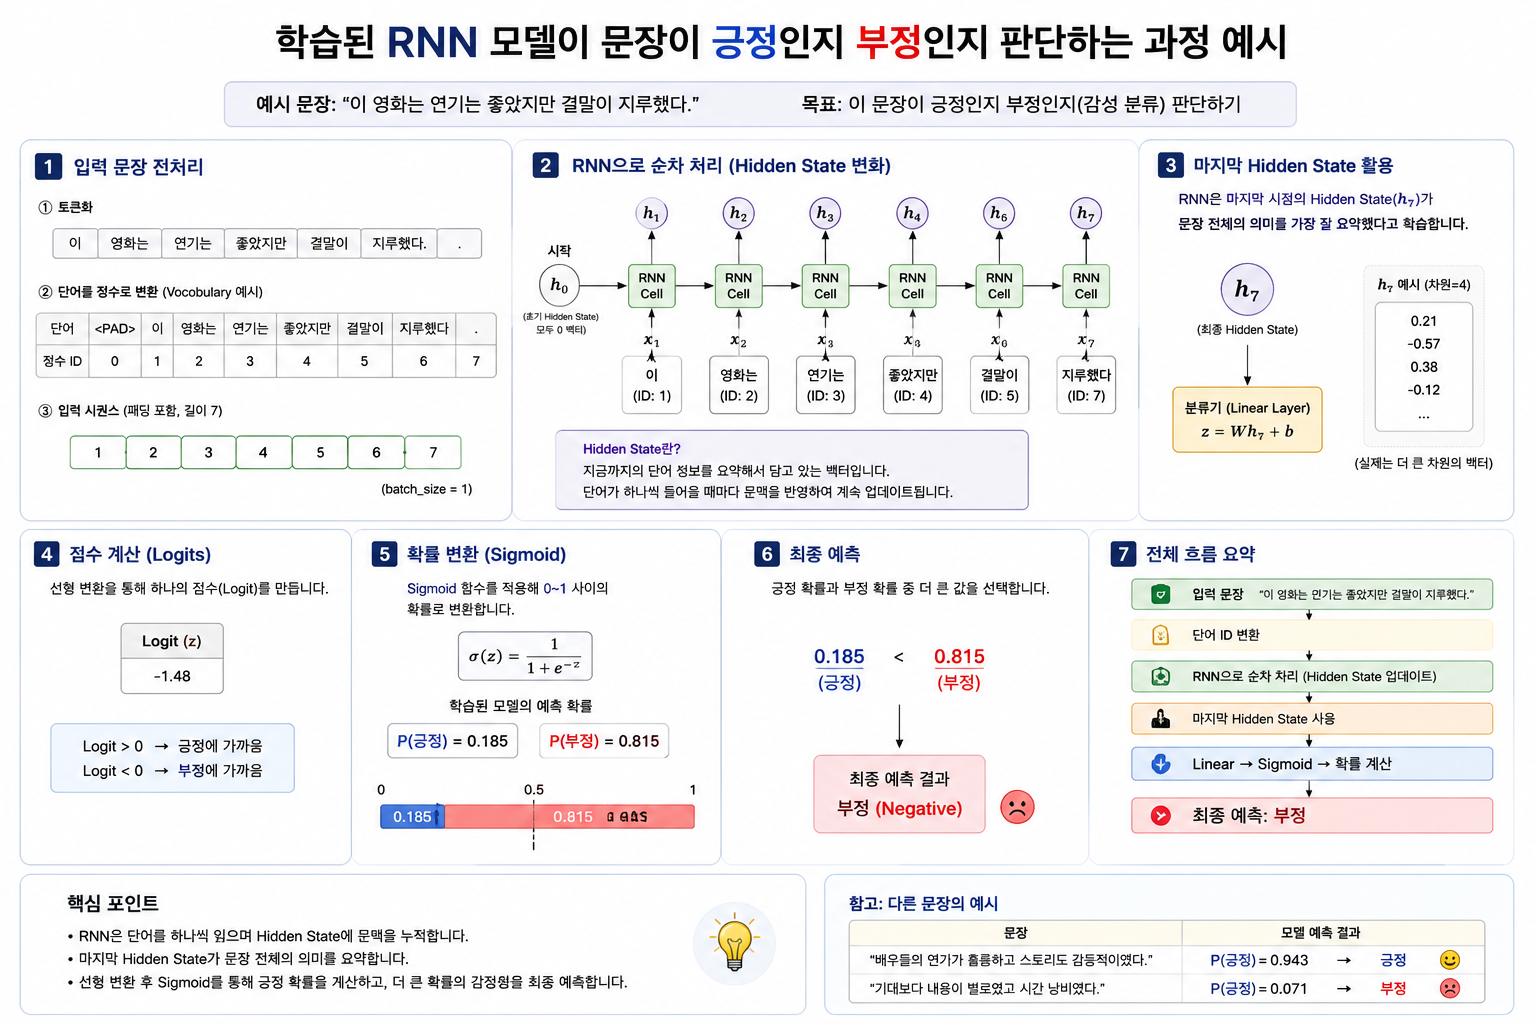

## 07. 기본 RNN의 한계와 다음 단계

기본 RNN은 이전 정보를 은닉 상태 하나에 계속 덮어쓰므로 시퀀스가 길어질수록 초반 정보가 약해질 수 있다. 역전파 과정에서 기울기 소실이 누적되면 멀리 떨어진 토큰 관계를 학습하기 어렵다.

gradient clipping은 지나치게 큰 기울기를 제한하지만 작은 기울기를 되살리지는 못한다. 다음 노트북의 LSTM은 셀 상태와 게이트를 추가하여 장기 의존성을 더 안정적으로 전달하고, GRU는 이를 더 단순한 구조로 구현한다.
